# Offline Dictionary Attack on a Password Authentication System

ECE 1155: Information Security - Cyberattack Demonstration and Mitigation - Ali Morsy

This notebook simulates a mock login system that stores password hashes in a user
database, then plays the role of an attacker who has stolen that database and runs
an **offline dictionary attack** against it. The same experiment is repeated twice:
once with the vulnerable configuration (unsalted **MD5**) and once with the
countermeasure applied (salted **bcrypt**), so the two can be compared directly.

Everything below uses a synthetic, in-memory database. No real credentials are used.

In [1]:
import hashlib  # MD5 hashing (stdlib)
import random  # password sampling / wordlist mangling
import string  # character sets for strong passwords
import time  # timing attack runs

import bcrypt  # salted, slow password hashing (the countermeasure)
import matplotlib.pyplot as plt  # plotting results

## Parameters

All knobs for the simulation are gathered here so the experiment can be rerun with
different settings without touching the logic below.

In [2]:
random.seed(42)  # reproducible demo results

num_accounts = 25  # number of user accounts in the simulated database

# Distribution of password complexity across the simulated accounts.
password_strength = {
    "weak": 0.5,     # pulled directly from the common-password wordlist
    "medium": 0.3,    # a common word plus a couple of digits
    "strong": 0.2,    # long random string, effectively uncrackable by dictionary
}

# Wordlist sizes to sweep over for each hash_algorithm. MD5 can be swept much
# further than bcrypt in the same notebook run because bcrypt is deliberately slow
# (see the attack function below). That gap in feasible wordlist size is itself
# part of what the countermeasure is demonstrating. bcrypt sizes are kept small
# on purpose: each candidate requires a real bcrypt.checkpw() call per account,
# so even a few dozen candidates take real wall-clock time (see README).
wordlist_sizes = {
    "md5": [10, 50, 100, 500, 1000, 5000, 10000],
    "bcrypt": [10, 25, 50],
}

hash_algorithms = ["md5", "bcrypt"]  # algorithms to compare
# bcrypt work factor (rounds = 2^bcrypt_cost). 
bcrypt_cost = 10

wordlist_path = "wordlist.txt"  # attacker's base dictionary / weak-password source

## Mock database generation

`generate_accounts` builds `num_accounts` synthetic (username, plaintext password)
pairs according to `password_strength`. `hash_database` then stores only the hash of
each password, exactly as a real authentication server would. The plaintexts are not
kept around, they only exist here so the demo can later report which ones were
actually recovered.

In [3]:
def load_base_wordlist(path):
    # Read one password per line into a list; skip blank lines.
    with open(path) as f:
        return [line.strip() for line in f if line.strip()]


def generate_accounts(num_accounts, password_strength, base_words):
    # Build num_accounts (username, plaintext_password) pairs. Each account's
    # password tier (weak/medium/strong) is chosen per password_strength weights.
    tiers = list(password_strength.keys()) # ["weak", "medium", "strong"]
    weights = list(password_strength.values()) # [0.5, 0.3, 0.2]
    strong_alphabet = string.ascii_letters + string.digits + "!@#$%^&*"

    accounts = []
    for i in range(num_accounts):
        tier = random.choices(tiers, weights=weights, k=1)[0] # randomly select a password tier
        if tier == "weak":
            password = random.choice(base_words)  # raw common password
        elif tier == "medium":
            password = random.choice(base_words) + str(random.randint(0, 99))  # word + digits
        else:  # strong
            password = "".join(random.choices(strong_alphabet, k=14))  # random 14-char string
        accounts.append((f"user{i:03d}", password)) # store the username and plaintext password
    return accounts


def hash_database(accounts, hash_algorithm, bcrypt_cost=12):
    # Mirror what a real server stores: only the hash, plaintext is discarded.
    hashed_accounts = []
    for username, password in accounts:
        if hash_algorithm == "md5":
            digest = hashlib.md5(password.encode()).hexdigest()  # fast, unsalted
        elif hash_algorithm == "bcrypt":
            digest = bcrypt.hashpw(
                password.encode(), bcrypt.gensalt(rounds=bcrypt_cost)  # random salt baked in
            ).decode()
        else:
            raise ValueError(f"Unsupported hash_algorithm: {hash_algorithm}")
        hashed_accounts.append((username, digest))
    return hashed_accounts


base_words = load_base_wordlist(wordlist_path)
accounts = generate_accounts(num_accounts, password_strength, base_words)

# Same plaintext passwords hashed both ways, so the two "leaked databases"
# below are directly comparable.
md5_db = hash_database(accounts, "md5")
bcrypt_db = hash_database(accounts, "bcrypt", bcrypt_cost)

print(f"Generated {len(accounts)} mock accounts.")
print("Example stored record (md5):", md5_db[0])
print("Example stored record (bcrypt):", bcrypt_db[0])

Generated 25 mock accounts.
Example stored record (md5): ('user000', '2dbd6605ac3b23d00bb03488d56281b0')
Example stored record (bcrypt): ('user000', '$2b$10$eh9n5.fXj0rlbyE7pyfGQ.weVUKR6Z2gMl.yfmbqQbxe66JNu/n2q')


## Wordlist preparation

A real attacker doesn't stop at the raw wordlist. Password crackers apply mangling
rules (appending digits, capitalizing, etc.) to multiply a base wordlist into a much
larger candidate set. `generate_synthetic_wordlist` mimics that by cycling through the
base words and appending an increasing numeric suffix until the requested
`wordlist_size` is reached.

In [4]:
def generate_synthetic_wordlist(base_words, target_size):
    # Expand base_words up to target_size by appending increasing numeric
    # suffixes (word0, word1, ...) -- simulates a cracker's mangling rules.
    candidates = list(dict.fromkeys(base_words))  # dedup, preserve order
    suffix = 0
    while len(candidates) < target_size:
        base = base_words[suffix % len(base_words)]
        mutated = f"{base}{suffix // len(base_words)}"
        if mutated not in candidates:
            candidates.append(mutated)
        suffix += 1
    return candidates[:target_size]

## Dictionary attack

`run_dictionary_attack` hashes each wordlist candidate and checks it against the
stolen database, entirely offline.

- **MD5** is unsalted, so identical passwords always produce identical hashes. This
  lets the attacker build a `hash -> username` lookup table once and check each
  candidate, which is why MD5 wordlists can be swept into the tens of
  thousands of entries in this notebook.
- **bcrypt** embeds a random salt in every hash, so there is no shortcut: each
  candidate must be checked against every remaining hash individually with
  `bcrypt.checkpw`, and the cost factor makes each single check slow by design. This
  is exactly the property that makes bcrypt an effective countermeasure, but it also
  means the bcrypt wordlist sizes here must stay much smaller for the notebook to
  finish in a reasonable time.

In [5]:
def run_dictionary_attack(hashed_accounts, wordlist, hash_algorithm):
    # Try every wordlist candidate against the stolen hashes.
    # Returns (percent of accounts cracked, seconds elapsed).
    start_time = time.time()
    cracked_count = 0

    if hash_algorithm == "md5":
        # No salt -> the same password always hashes the same way, so build one
        # hash->username table up front and do an O(1) lookup per candidate.
        hash_to_username = {digest: user for user, digest in hashed_accounts}
        for candidate in wordlist:
            candidate_hash = hashlib.md5(candidate.encode()).hexdigest()
            if candidate_hash in hash_to_username:
                cracked_count += 1
                del hash_to_username[candidate_hash]  # don't recount on a later match
    elif hash_algorithm == "bcrypt":
        # Random salt per hash -> no shortcut; each candidate must be checked
        # against every remaining hash individually (slow by design).
        remaining = list(hashed_accounts)
        for candidate in wordlist:
            candidate_bytes = candidate.encode()
            still_remaining = []
            for username, digest in remaining:
                if bcrypt.checkpw(candidate_bytes, digest.encode()):
                    cracked_count += 1
                else:
                    still_remaining.append((username, digest))
            remaining = still_remaining  # drop cracked accounts from future checks
    else:
        raise ValueError(f"Unsupported hash_algorithm: {hash_algorithm}")

    elapsed_seconds = time.time() - start_time
    percent_cracked = 100 * cracked_count / len(hashed_accounts)
    return percent_cracked, elapsed_seconds

## Experiment sweep

Run the attack across every configured `wordlist_size` for both hash algorithms and
collect the results for plotting.

In [6]:
results = []  # one dict per (algorithm, wordlist_size) run

for hash_algorithm in hash_algorithms:
    hashed_db = md5_db if hash_algorithm == "md5" else bcrypt_db
    for size in wordlist_sizes[hash_algorithm]:
        wordlist = generate_synthetic_wordlist(base_words, size)
        percent_cracked, elapsed_seconds = run_dictionary_attack(
            hashed_db, wordlist, hash_algorithm
        )
        results.append(
            {
                "algorithm": hash_algorithm,
                "wordlist_size": size,
                "percent_cracked": percent_cracked,
                "elapsed_seconds": elapsed_seconds,
            }
        )
        print(
            f"{hash_algorithm:>6} | wordlist_size={size:>6} | "
            f"cracked={percent_cracked:5.1f}% | time={elapsed_seconds:.4f}s"
        )

   md5 | wordlist_size=    10 | cracked=  0.0% | time=0.0001s
   md5 | wordlist_size=    50 | cracked= 12.0% | time=0.0001s
   md5 | wordlist_size=   100 | cracked= 28.0% | time=0.0001s
   md5 | wordlist_size=   500 | cracked= 40.0% | time=0.0005s
   md5 | wordlist_size=  1000 | cracked= 44.0% | time=0.0011s
   md5 | wordlist_size=  5000 | cracked= 52.0% | time=0.0049s
   md5 | wordlist_size= 10000 | cracked= 52.0% | time=0.0115s
bcrypt | wordlist_size=    10 | cracked=  0.0% | time=13.8921s
bcrypt | wordlist_size=    25 | cracked=  4.0% | time=34.7939s
bcrypt | wordlist_size=    50 | cracked= 12.0% | time=77.6266s


## Results

Two measurable outputs, as specified in the project proposal:
1. Percentage of accounts cracked vs. wordlist size.
2. Crack time vs. hash algorithm, for a matched wordlist size. This is the
   before/after view of the bcrypt countermeasure.

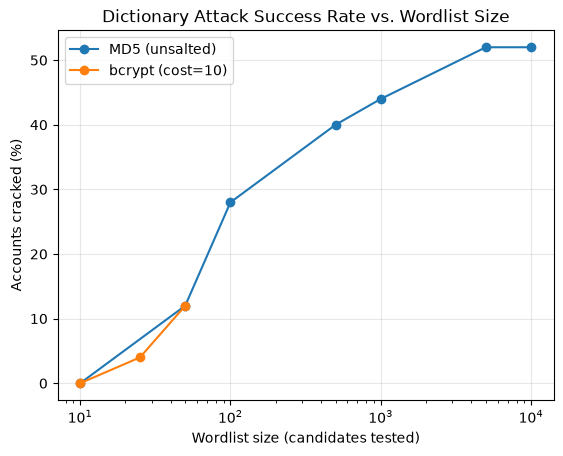

In [7]:
# Split results back out by algorithm for plotting.
md5_results = [r for r in results if r["algorithm"] == "md5"]
bcrypt_results = [r for r in results if r["algorithm"] == "bcrypt"]

plt.figure()
plt.plot(
    [r["wordlist_size"] for r in md5_results],
    [r["percent_cracked"] for r in md5_results],
    marker="o",
    label="MD5 (unsalted)",
)
plt.plot(
    [r["wordlist_size"] for r in bcrypt_results],
    [r["percent_cracked"] for r in bcrypt_results],
    marker="o",
    label="bcrypt (cost=10)",
)
plt.xscale("log")  # wordlist sizes span orders of magnitude
plt.xlabel("Wordlist size (candidates tested)")
plt.ylabel("Accounts cracked (%)")
plt.title("Dictionary Attack Success Rate vs. Wordlist Size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

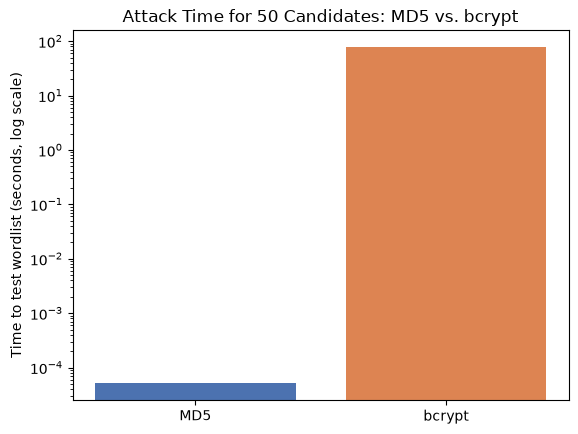

In [8]:
# Compare attack time at a wordlist size present in both sweeps.
common_size = 50
md5_time = next(r["elapsed_seconds"] for r in md5_results if r["wordlist_size"] == common_size)
bcrypt_time = next(
    r["elapsed_seconds"] for r in bcrypt_results if r["wordlist_size"] == common_size
)

plt.figure()
plt.bar(["MD5", "bcrypt"], [md5_time, bcrypt_time], color=["#4C72B0", "#DD8452"])
plt.yscale("log")  # bcrypt is orders of magnitude slower than MD5
plt.ylabel("Time to test wordlist (seconds, log scale)")
plt.title(f"Attack Time for {common_size} Candidates: MD5 vs. bcrypt")
plt.show()

## Summary

In [9]:
slowdown = bcrypt_time / md5_time if md5_time > 0 else float("inf")

print(f"At wordlist_size={common_size}:")
print(f"  MD5    took {md5_time:.4f}s to test {common_size} candidates")
print(f"  bcrypt took {bcrypt_time:.4f}s to test {common_size} candidates")
print(f"  bcrypt is ~{slowdown:,.0f}x slower per wordlist than MD5 at cost={bcrypt_cost}")
print()
print(f"MD5 largest sweep ({max(wordlist_sizes['md5'])} candidates): "
      f"{md5_results[-1]['percent_cracked']:.1f}% of accounts cracked")
print(f"bcrypt largest sweep ({max(wordlist_sizes['bcrypt'])} candidates): "
      f"{bcrypt_results[-1]['percent_cracked']:.1f}% of accounts cracked")

At wordlist_size=50:
  MD5    took 0.0001s to test 50 candidates
  bcrypt took 77.6266s to test 50 candidates
  bcrypt is ~1,500,412x slower per wordlist than MD5 at cost=10

MD5 largest sweep (10000 candidates): 52.0% of accounts cracked
bcrypt largest sweep (50 candidates): 12.0% of accounts cracked
